From Campusx youtube

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/heart.csv")

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.shape

(303, 14)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
X = df.drop(columns=['target'])
y= df['target']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(241, 13)
(61, 13)


**Akbr train test split ke wajase calculating accuracy score if you do crossvalidate then accuracy thora ghat jata hai**

Using RandomForestClassifier without Hyperparameter Tunning

In [ ]:
rf = RandomForestClassifier()
print('Random Forest:')
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
accuracy_score(y_test,y_pred)

Random Forest:


0.8524590163934426

check with another algorithm also how its working like in gradientbosstclassifier,svm,logisticregression

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
gd = GradientBoostingClassifier()
lr = LogisticRegression()
svc = SVC()

In [ ]:
print("GradientBoost:")
gd.fit(x_train,y_train)
y_pred = gd.predict(x_test)
accuracy_score(y_test,y_pred)

GradientBoost:


0.8524590163934426

In [ ]:
print("LogisticRegression:")
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
accuracy_score(y_test,y_pred)

LogisticRegression:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8524590163934426

In [ ]:
print("SVM:")
svc.fit(x_train,y_train)
y_pred = svc.predict(x_test)
accuracy_score(y_test,y_pred)

SVM:


0.7049180327868853

Using cross Validation check accuracy score

In [ ]:
from sklearn.model_selection import cross_val_score
print('Random Forest')
np.mean(cross_val_score(RandomForestClassifier(),X,y,cv=10,scoring='accuracy')) #10 bar same kaam karke average nikala,so this score is jyada accurate representation.


Random Forest


np.float64(0.8176344086021505)

In [ ]:
from sklearn.model_selection import cross_val_score
print('Gradient Boost')
np.mean(cross_val_score(GradientBoostingClassifier(),X,y,cv=10,scoring='accuracy'))

Gradient Boost


np.float64(0.8044086021505377)

In [ ]:
from sklearn.model_selection import cross_val_score
print('SVM')
np.mean(cross_val_score(SVC(),X,y,cv=10,scoring='accuracy'))

SVM


np.float64(0.6522580645161289)

In [ ]:
from sklearn.model_selection import cross_val_score
print('Logistic Regression')
np.mean(cross_val_score(LogisticRegression(),X,y,cv=10,scoring='accuracy'))

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.827741935483871)

We can improve the score of Random Forest if we do hyperparameter tunning  
**With HyperparameterTunning**

In [ ]:
rf = RandomForestClassifier(max_samples=0.75,random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy_score(y_test,y_pred) #withou using hyperparameter score was 85%,now its increase

0.8688524590163934

using cross validation and hyperparameter

In [ ]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(RandomForestClassifier(max_samples=0.75),X,y,cv=10,scoring='accuracy')) #before using only cv score was 81%

np.float64(0.8275268817204301)

the problem is random forest me arounf 25 hyperparameter hai..yahape sirf max_samples ko check kiye.par mujhe kaise pata chalega ki har parameter ka sabse sahi value kya hoga.iska solution hai **Hyperparameter Tunning**-->Types i)grid search ii) random search

**GridSearchCV**  
isme aap har ak parameter ko alag alag values de dete ho jinke liye apko test karna hai.har particular combination ke liye ak random forest train hoga.so total here combination will be=4*3*3*3=108 combinations.  
hum 108 different random forest train karenge.ye grid ki tarah hai,if 4 parameters ko tune kar reheho it means tab app ak 4 dimensional grid/table ho or app us table ke har ak value ke liye apne random forest ko train karoge.

In [ ]:
#Number of trees(base learners.for random forest base learner is decision tree) in random forest.
n_estimators = [20, 60, 100, 120] #4

#Number of features(columns) to consider at every split
max_features = [0.2, 0.6, 1.0]  #3

#Maximum number of levels in the tree
max_depth = [2, 8, None]  #3

#Number of Samples(Rows from your training dataset)
max_samples = [0.5, 0.75, 1.0]  #3

#so 4*3*3*3 = 108 combination of trees

In [ ]:
#now ak dictionary ke andar hyperparameter name and hyperparameter value pass karte ho

param_grid = {
    'n_estimators' : n_estimators,
    'max_features' : max_features,
    'max_depth'    : max_depth,
    'max_samples'   : max_samples
}

print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0]}


In [ ]:
rf = RandomForestClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV

#yahape 4 se 5 ciz add karna hai-->estimators means konsa algorithm ko apko run karna hai,param_grid = kya kya option ke upar train karna hai,cv =5 means
#har random foresrt jo 108 ka combination hai usme har ak random forest ko 5 bar karke train karo(you will get accurate result).verbose = during the process kaise
#chiz ho raha hai woo show karega, n_jobs me process thora fast ho jayega.

rf_grid = GridSearchCV(estimator=rf,
                       param_grid=param_grid,
                       cv=5,
                       verbose=2,
                       n_jobs=-1)

In [ ]:
rf_grid.fit(x_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [ ]:
rf_grid.best_params_

{'max_depth': 2, 'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 60}

In [ ]:
rf_grid.best_score_

np.float64(0.8505952380952382)

**RandomSearchCV**

In [ ]:
#Number of trees(base learners.for random forest base learner is decision tree) in random forest.
n_estimators = [20, 60, 100, 120]

#Number of features(columns) to consider at every split
max_features = [0.2, 0.6, 1.0]

#Maximum number of levels in the tree
max_depth = [2, 8, None]

#Number of Samples(Rows from your training dataset)
max_samples = [0.5, 0.75, 1.0]

#Bootstrap samples True mean with replacement, False means Without replacement
bootstrap = [True,False]

#minimum number of samples required to split a node(to create child node)
min_samples_split = [2,5]

#Minimum number of samples required at each leaf node
min_samples_leaf = [1,2]

In [ ]:
param_grid = {
    'n_estimators' : n_estimators,
    'max_features' : max_features,
    'max_depth'    : max_depth,
    'max_samples'  : max_samples,
    'bootstrap'    : bootstrap,
    'min_samples_split' : min_samples_split,
    'min_samples_leaf'  : min_samples_leaf
}

print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0], 'bootstrap': [True, False], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_random= RandomizedSearchCV(estimator=rf,
                              param_distributions=param_grid,
                              verbose=2,
                              n_jobs=-1,
                              cv=5)

In [ ]:
#randomizedsearch me randolmy select karta hai isiliye time kam lagta hai for large dataset..near to perfect result deta hai kaam time me..
#for small dataset go with grid search
#for large dataset go for randizedsearch

rf_random.fit(x_train,y_train) #so here it randomly choose 10 candidates



Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [ ]:
rf_random.best_params_

{'n_estimators': 60,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_samples': 1.0,
 'max_features': 0.2,
 'max_depth': 2,
 'bootstrap': True}

In [ ]:
rf_random.best_score_

np.float64(0.8423469387755101)

**Out Of Bag(OOB)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/heart.csv")

In [ ]:
X = df.drop(columns=['target'])
y= df['target']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
rf = RandomForestClassifier(oob_score = True)
print('Random Forest:')
rf.fit(x_train,y_train)


Random Forest:


RandomForestClassifier(oob_score=True)

In [ ]:
#out of bag se validate karke score is 80%,thora vary kar raha hai..par apko ak roughly ak estimate mil jata hai ki apke model ka accuracy kaisa jaa raha hai..
rf.oob_score_

0.8099173553719008

In [ ]:
#normall score using test data is 85%
y_pred = rf.predict(x_test)
accuracy_score(y_test,y_pred)

0.8524590163934426

**Random Forest Classification By Adhya Mam**

customerID: A unique identifier for each customer.  
gender: The gender of the customer (Male/Female).  
SeniorCitizen: Indicates if the customer is a senior citizen (1 = Yes, 0 = No).  
Partner: Indicates if the customer has a partner (Yes/No).  
Partner: Indicates if the customer has a partner (Yes/No).  
Dependents: Indicates if the customer has dependents (Yes/No).  
tenure: Number of months the customer has stayed with the company.  
PhoneService: Indicates if the customer has a phone service (Yes/No).  
MultipleLines: Indicates if the customer has multiple lines (Yes/No/No phone service).  
InternetService: Type of internet service (DSL, Fiber optic, None).  
OnlineSecurity: Indicates if the customer has online security add-ons (Yes/No/No internet service).  
DeviceProtection: Indicates if the customer has device protection add-ons (Yes/No/No internet service).  
TechSupport: Indicates if the customer has tech support add-ons (Yes/No/No internet service).  
StreamingTV: Indicates if the customer streams TV services (Yes/No/No internet service).  
StreamingMovies: Indicates if the customer streams movies (Yes/No/No internet service).  
Contract: Type of contract (Month-to-month, One year, Two year).  
PaperlessBilling: Indicates if the customer uses paperless billing (Yes/No).  
PaymentMethod: The payment method used (e.g., Electronic check, Mailed check, Bank transfer, Credit card).  
MonthlyCharges: Monthly charges for the customer.  
TotalCharges: Total charges billed to the customer.  
Churn: Indicates if the customer has churned (Yes/No).  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/customer_churn.csv")

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

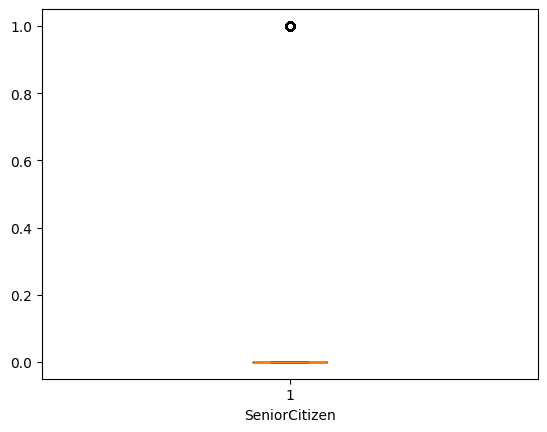

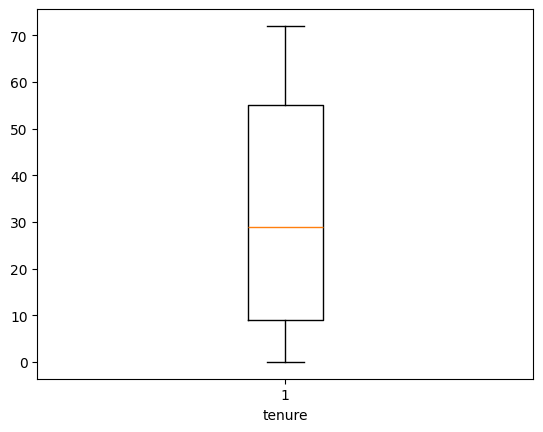

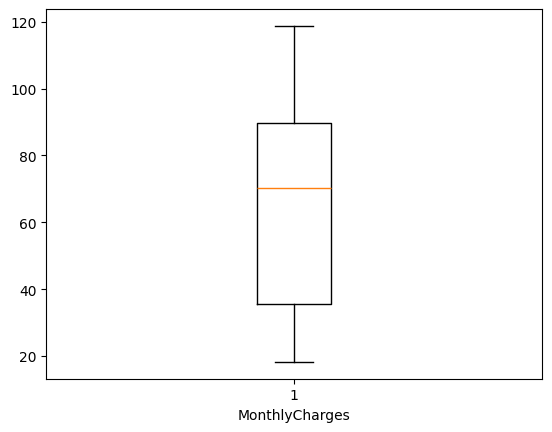

In [ ]:
for i in df.columns:
    if df[i].dtype != "object":
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#total charges is in object type we have to change it into float
df['TotalCharges'] = df['TotalCharges'].astype(float)

ValueError: could not convert string to float: ' '

In [ ]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
#as it is in numeric but only probelm is datatype is in object because some data in that column that it not numeric it may be '?' this kind of things.so we can use to_numeric method to conver
#object type into float and where there was '?' this type of value that will be replace will NAN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [ ]:
df['TotalCharges'].dtype

dtype('float64')

In [ ]:
#as we have converted object to float so we have to check the null values
df.isnull().sum().sum()

np.int64(11)

In [ ]:
#df.dropna wont work you have to give inplace= True also
df.dropna(inplace= True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#will do label encoding because with object we cannot apply random forest or any algoithm
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5365,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3953,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5524,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4843,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1990.50,0
7039,1524,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,7362.90,0
7040,3358,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,346.45,0
7041,5923,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,306.60,1


In [ ]:
#you can see all object type has changed into int type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   int64  
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   int64  
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   int64  
 16  PaperlessBilling  7032 non-null   int64  
 17  

Target column/Output column will consider churn column

In [ ]:
x = df.drop(columns = "Churn") #x= df.iloc[:,:-1]
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify = y)

In [ ]:
#n_estimators-- number of trees in the forest/how many decision tree you need to consider. the number is up to you
#max_depth = in each decision tree how much length of the particular tree should be there
model = RandomForestClassifier(n_estimators = 50,random_state = 37,max_depth = 5)

In [ ]:
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=50, random_state=37)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test,y_pred)

0.783226723525231

In [ ]:
n_estimators = [50,100,150,200,250,300,350,400,450,500,550,600]

In [ ]:
#we took n_estimator = 50 and got accuracy 79% we can take a loop and check in which n_estimators we are getting more or best accuracy
#we are checking in a temporary model
for i in n_estimators:
    temp_model = RandomForestClassifier(n_estimators = i,random_state = 37)
    temp_model.fit(x_train,y_train)
    y_temp_pred = model.predict(x_test)
    acc = accuracy_score(y_test,y_temp_pred)
    print(f"the accuracy for n_estimators {i} is {acc}" )

the accuracy for n_estimators 50 is 0.783226723525231
the accuracy for n_estimators 100 is 0.783226723525231
the accuracy for n_estimators 150 is 0.783226723525231
the accuracy for n_estimators 200 is 0.783226723525231
the accuracy for n_estimators 250 is 0.783226723525231
the accuracy for n_estimators 300 is 0.783226723525231
the accuracy for n_estimators 350 is 0.783226723525231
the accuracy for n_estimators 400 is 0.783226723525231
the accuracy for n_estimators 450 is 0.783226723525231
the accuracy for n_estimators 500 is 0.783226723525231
the accuracy for n_estimators 550 is 0.783226723525231
the accuracy for n_estimators 600 is 0.783226723525231


In [ ]:
#for logistic Regression and decision tree
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
ans = lr.predict(x_test)
accuracy_score(ans,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7768301350390903

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 3)
model.fit(x_train,y_train)
model.predict(x_test)
x = accuracy_score(y_test,y_pred)
x

0.783226723525231

**Using GridSearchCV**

In [ ]:
n_estimators = [20,30,50,100,120] #5
max_depth = [2,5,None] #3
max_features = [0.2,0.5,1.0] #3
max_samples = [0.5,0.8,0.75,1.0] #4
bootstrap = [True,False] #2
#5*3*3*4*2 =  360 candidates in the grid
#and we will apply cv=5 means 360*5 = 1800 fits

In [ ]:
param_grid = {
    'n_estimators' : n_estimators,
    'max_depth'    : max_depth,
    'max_features' : max_features,
    'max_samples'  : max_samples,
    'bootstrap'    : bootstrap
}
print(param_grid)

{'n_estimators': [20, 30, 50, 100, 120], 'max_depth': [2, 5, None], 'max_features': [0.2, 0.5, 1.0], 'max_samples': [0.5, 0.8, 0.75, 1.0], 'bootstrap': [True, False]}


In [ ]:
rf = RandomForestClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_grid = GridSearchCV(estimator= rf ,
                       param_grid=param_grid,
                       verbose=2,
                       cv=5,
                       scoring='accuracy')

In [ ]:
rf_grid.fit(x_train,y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=30; total time=   0.3s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=30; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=30; total time=   0.3s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samp

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
900 fits failed out of a total of 1800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
900 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueEr

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [2, 5, None],
                         'max_features': [0.2, 0.5, 1.0],
                         'max_samples': [0.5, 0.8, 0.75, 1.0],
                         'n_estimators': [20, 30, 50, 100, 120]},
             scoring='accuracy', verbose=2)

In [ ]:
rf_grid.best_score_

np.float64(0.8016)

In [ ]:
rf_grid.best_params_

{'bootstrap': True,
 'max_depth': 5,
 'max_features': 0.5,
 'max_samples': 0.5,
 'n_estimators': 50}

**Using RandomSearchCV**

In [ ]:
n_estimators = [20,30,50,100,120] #5
max_depth = [2,5,None] #3
max_features = [0.2,0.5,1.0] #3
max_samples = [0.5,0.8,0.75,1.0] #4
bootstrap = [True,False] #2

In [ ]:
param_grid = {
    'n_estimators' : n_estimators,
    'max_depth'    : max_depth,
    'max_features' : max_features,
    'max_samples'  : max_samples,
    'bootstrap'    : bootstrap
}

In [ ]:
rf = RandomForestClassifier()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator= rf ,
                       param_distributions=param_grid,
                       verbose=2,
                       cv=5,
                       scoring='accuracy')

In [ ]:
rf_random.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.4s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.4s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, max_samples=1.0, n_estimators=50; total time=   0.6s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, max_samples=1.0, n_estimators=50; total time=   0.6s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, max_samples=1.0, n_estimators=50; total time=   0.6s
[CV] END bootstrap=True, max_depth=5, max_features=0

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 5, None],
                                        'max_features': [0.2, 0.5, 1.0],
                                        'max_samples': [0.5, 0.8, 0.75, 1.0],
                                        'n_estimators': [20, 30, 50, 100, 120]},
                   scoring='accuracy', verbose=2)

In [ ]:
rf_random.best_score_

np.float64(0.8005333333333333)

In [ ]:
rf_random.best_params_

{'n_estimators': 20,
 'max_samples': 1.0,
 'max_features': 0.5,
 'max_depth': 5,
 'bootstrap': True}

OOB (Out Of Bag)

In [ ]:
n_estimators = [20,30,50,100,120] #5
max_depth = [2,5,None] #3
max_features = [0.2,0.5,1.0] #3
max_samples = [0.5,0.8,0.75,1.0] #4
bootstrap = [True,False] #2

In [ ]:
param_grid = {
    'n_estimators' : n_estimators,
    'max_depth'    : max_depth,
    'max_features' : max_features,
    'max_samples'  : max_samples,
    'bootstrap'    : bootstrap
}

In [ ]:
rf = RandomForestClassifier(oob_score=True)
rf.fit(x_train,y_train)

RandomForestClassifier(oob_score=True)

In [ ]:
rf.oob_score_

0.7932444444444444

In [ ]:
from sklearn.model_selection import GridSearchCV
rf_random = GridSearchCV(estimator= rf ,
                       param_grid=param_grid,
                       verbose=2,
                       cv=5,
                       scoring='accuracy')

In [ ]:
rf_random.fit(x_train,y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.3s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=30; total time=   0.4s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=30; total time=   0.3s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=30; total time=   0.3s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samp

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=30; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=30; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=30; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=30; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=30; total time=   0.1s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=50; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=50; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=50; total time=   0.2s
[CV] END bootstrap=True, max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=50; total time=   0.5s
[CV] END bootstrap=

...

[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=20; total time=   0.7s


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=20; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=30; total time=   1.1s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=30; total time=   0.9s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=30; total time=   0.8s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=30; total time=   0.8s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=30; total time=   0.8s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=50; total time=   1.3s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=50; total time=   1.3s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, max_samples=1.0, n_estimators=50; total time=

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
900 fits failed out of a total of 1800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
900 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueEr

GridSearchCV(cv=5, estimator=RandomForestClassifier(oob_score=True),
             param_grid={'bootstrap': [True, False], 'max_depth': [2, 5, None],
                         'max_features': [0.2, 0.5, 1.0],
                         'max_samples': [0.5, 0.8, 0.75, 1.0],
                         'n_estimators': [20, 30, 50, 100, 120]},
             scoring='accuracy', verbose=2)

In [ ]:
rf_random.best_estimator_

RandomForestClassifier(max_depth=5, max_features=0.5, max_samples=0.5,
                       n_estimators=50, oob_score=True)

In [ ]:
rf_random.best_score_

np.float64(0.8035555555555556)

In [ ]:
rf.oob_score_

0.7932444444444444

So we can tell rf_random giving lagbhag correct prediction

**Random Forest Regression**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/Boston (1).csv")

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [9]:
X = df.drop(columns=['medv'])
y = df['medv']

In [10]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()

In [14]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Normal Random Forest without Hyperparameter

In [15]:
rd_forest = RandomForestRegressor()
rd_forest.fit(x_train,y_train)
y_pred = rd_forest.predict(x_test)
r2_score(y_test,y_pred)

0.8823922198023637

**Hyperparameter Tunning**  


In [16]:
max_depth = [2,5,None,8]
max_features = [0.2,0.5,1.0,0.8]
max_samples = [0.2,0.5,1.0,0.8]
n_estimators = [10,20,30,60]
bootstrap = [True,False]
min_samples_split = [2,5]
min_samples_leaf = [1,2]

In [17]:
param_grid = {
    'max_depth' : max_depth,
    'max_features' : max_features,
    'max_samples'  : max_samples,
    'n_estimators'  : n_estimators,
    'bootstrap'  : bootstrap,
    'min_samples_split' : min_samples_split,
    'min_samples_leaf'  : min_samples_leaf
}

In [18]:
random_forest = RandomForestRegressor()

**GridSearchCV**

In [21]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = random_forest,
                       param_grid=param_grid,
                       cv = 5,
                       verbose=2,
                       scoring='r2',
                       n_jobs= -1)

In [22]:
rf_grid.fit(x_train,y_train)

Fitting 5 folds for each of 2048 candidates, totalling 10240 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5120 fits failed out of a total of 10240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5120 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
Valu

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [2, 5, None, 8],
                         'max_features': [0.2, 0.5, 1.0, 0.8],
                         'max_samples': [0.2, 0.5, 1.0, 0.8],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [10, 20, 30, 60]},
             scoring='r2', verbose=2)

In [23]:
rf_grid.best_score_

np.float64(0.8431235735105203)

In [24]:
rf_grid.best_params_

{'bootstrap': True,
 'max_depth': None,
 'max_features': 0.5,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 60}

**RandomizedSearchCV**

In [25]:
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(estimator=random_forest,
                               cv=5,
                               param_distributions=param_grid,
                               verbose=2,
                               n_jobs=-1)

In [26]:
rf_random.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 5, None, 8],
                                        'max_features': [0.2, 0.5, 1.0, 0.8],
                                        'max_samples': [0.2, 0.5, 1.0, 0.8],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [10, 20, 30, 60]},
                   verbose=2)

In [27]:
rf_random.best_score_

np.float64(0.8169423123223314)